<a href="https://colab.research.google.com/github/Caory2/Teoria_de_Aprendizaje_de_Maquina/blob/main/TAREA9_Introduction_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Ahora extenderemos el perceptrón simple, a arquitecturas más complejas que puedan ser paralelizadas mediante GPU utilizando TensorFlow y Keras, y que además permitan el cálculo automático de las derivadas.

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
tf.__version__

'2.20.0'

- Comencemos cargando el conjunto de datos **Fashion MNIST**.

- Keras tiene una serie de funciones para cargar conjuntos de datos populares en *keras.datasets*.

- El conjunto de datos ya está dividido entre un **conjunto de entrenamiento** y un **conjunto de prueba**, pero puede ser útil dividir aún más el conjunto de entrenamiento para tener un **conjunto de validación**:

In [ ]:
fashion_mnist = keras.datasets.fashion_mnist #cargar fashion mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

El **conjunto de entrenamiento** contiene 60,000 imágenes en escala de grises, cada una de $28\times 28$ píxeles:

In [ ]:
X_train_full.shape

(60000, 28, 28)

Cada intensidad de píxel se representa como un byte (0 a 255):

In [ ]:
X_train_full.dtype

dtype('uint8')

- Dividamos el **conjunto de entrenamiento** completo en un **conjunto de validación** y un conjunto de entrenamiento (*más pequeño*) mediante la estrategia de validación HoldOut.

- También **escalamos las intensidades de píxeles hasta el rango 0-1** y las convertimos en flotantes, dividiéndolas por 255.

In [ ]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

Se puede graficar una imagen usando la función *imshow()* de Matplotlib, con un mapa de color 'binario':

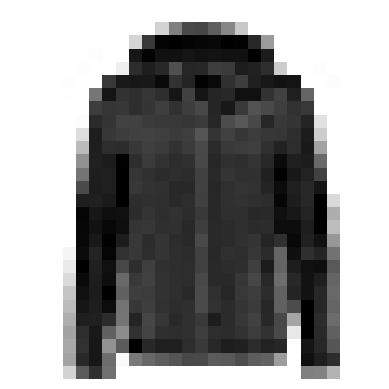

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

Las etiquetas son los ID de clase (representados como *uint8*), de 0 a 9:

In [ ]:
y_train

array([4, 0, 7, ..., 3, 0, 5], dtype=uint8)

Aquí están los nombres de clase correspondientes:

In [ ]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

Entonces, la primera imagen en el conjunto de entrenamiento es un abrigo:

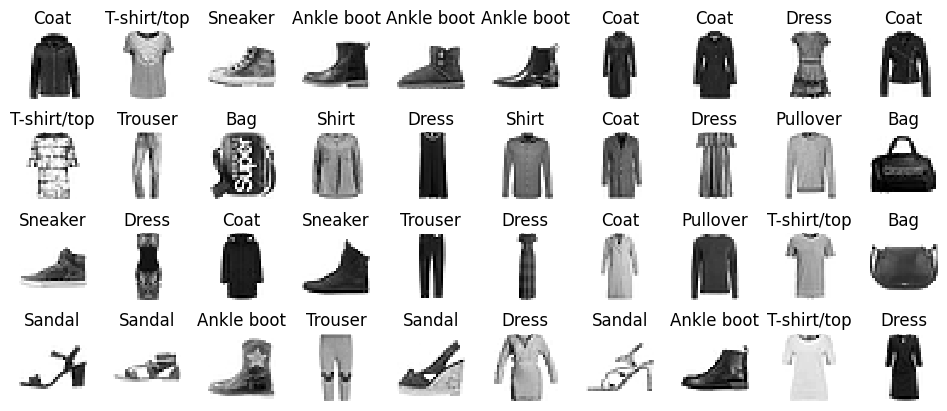

In [ ]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
#save_fig('fashion_mnist_plot', tight_layout=False)
plt.show()

In [ ]:
keras.backend.clear_session() #se sugiere limpiar la sesión para liberar los grafos computacionales
np.random.seed(42) #se fija semilla de numpy y tf
tf.random.set_seed(42)

En lugar de agregar las capas una por una como acabamos de hacer, se puede **pasar una lista de capas al crear el modelo secuencial**:

In [ ]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

- Las capas quedan guardadas en un grafo computacional para facilitar el cálculo de derivadas automáticas y la paralelización en GPU/TPU.

In [ ]:
model.layers

[<Flatten name=flatten_1, built=True>,
 <Dense name=dense_3, built=True>,
 <Dense name=dense_4, built=True>,
 <Dense name=dense_5, built=True>]

# Modelo y optimización en aprendizaje profundo

- En general, un modelo de aprendizaje profundo se puede escribir como una función compuesta de la forma:

$$\hat{y}=(f_L\circ f_{L-1}\circ\cdots\circ f_1)(\mathbf{x})$$

donde $L$ representa el número de capas y:

$$\mathbf{z}_l=f_l(\mathbf{z}_{l-1})=\varphi(\mathbf{z}_{l-1}\mathbf{W}_{l}+\mathbf{b}_l)$$
donde $\varphi(\cdot)$ es una función de activación, $\mathbf{W}_{l}\in\mathbb{R}^{Q_{l-1}\times Q_{l}},$ $\mathbf{b}_{l}\in\mathbb{R}^{Q_{l}},$ $\mathbf{z}_l\in\mathbb{R}^{Q_l}$ y $Q_l$ representa la cantidad de neuronas en la $l$-ésima capa.

- A partir del modelo planteado, se puede generar el siguiente problema de optimización:

$$\theta^* = \arg\min_{\theta} \mathbb{E}\{\mathscr{L}(y_n,\hat{y}_n|\theta): \forall n \in \{1,2,\dots,N\}\}$$
donde $\theta = \{\mathbf{W}_l,\mathbf{b}_l\}^L_{l=1}$ contiene el set de parámetros de la red y $\mathscr{L}(\cdot,\cdot|\theta)$ es una función de costo dada.



- Se puede resumir la arquitectura y presentar mediante diagrama de bloques:

In [ ]:
model.summary() #resumen con numero de parámetros y entradas-salidas por capa

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

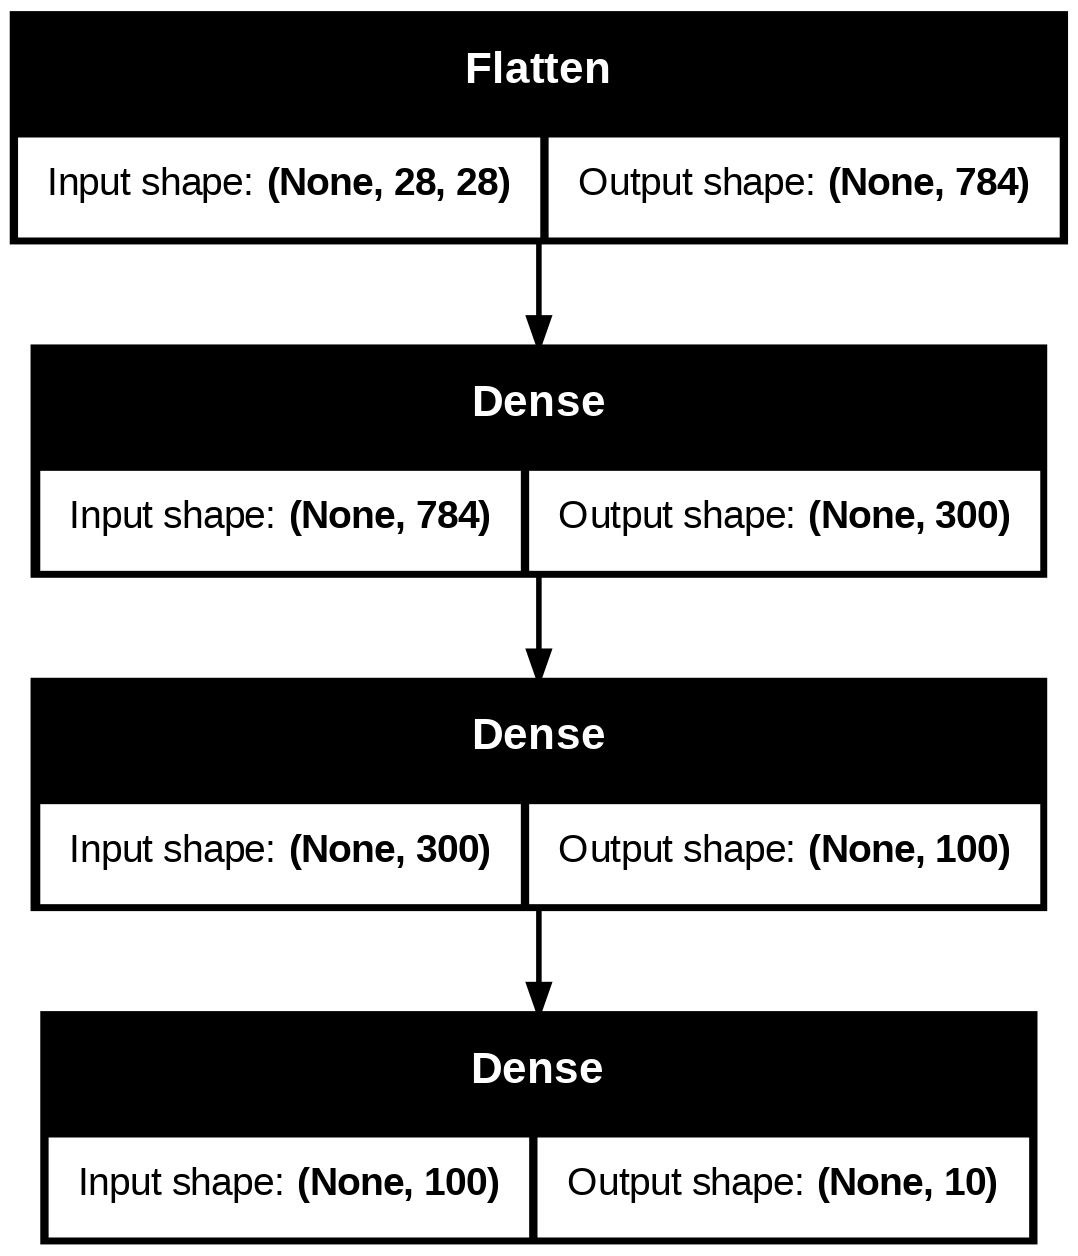

In [ ]:
keras.utils.plot_model(model, "my_mnist_model.png", show_shapes=True)

In [ ]:
hidden1 = model.layers[1] #acceder a la primera capa densa
hidden1.name

'dense'

In [ ]:
model.get_layer(hidden1.name) is hidden1 #también podemos acceder a la capa por su nombre

True

## Accediendo a los pesos y bias entrenados

- Con el fin de favorecer el entrenamiento, los pesos de cada capa se inicializan de forma aleatoria. Los bias se inicializan en ceros.

In [ ]:
weights, biases = hidden1.get_weights()

In [ ]:
weights

array([[ 0.06243706, -0.0320271 , -0.00958884, ...,  0.07233195,
        -0.02344332, -0.04050836],
       [-0.07405373, -0.04337782, -0.02531241, ..., -0.02096467,
        -0.0138748 ,  0.06047414],
       [-0.07433266,  0.00463492, -0.06392025, ...,  0.01268461,
         0.05191486, -0.06336167],
       ...,
       [-0.04328239, -0.04561137,  0.04431909, ...,  0.04910191,
         0.03910961, -0.03938591],
       [-0.04950883, -0.03391886, -0.03435994, ...,  0.05524929,
        -0.06135041,  0.06939304],
       [-0.05934712, -0.031324  ,  0.0411628 , ..., -0.00464568,
        -0.01634054, -0.00817741]], dtype=float32)

In [ ]:
weights.shape

(784, 300)

In [ ]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [ ]:
biases.shape

(300,)

### Compilando el modelo

- Después de crear un modelo, debe llamar a su método *compile()* para especificar la función de pérdida y el optimizador a utilizar.

- Opcionalmente, también puede especificar una lista de métricas adicionales para calcular durante el entrenamiento y la evaluación.

- En general, la función de costo se elige en términos de la tarea (rango de la función), y se buscan funciones de costo suaves, que no tengan problemas con sus derivadas, con el objetivo de aplicar gradiente descendiente por mini-lotes mediante el algoritmo de backpropagation.


- **Esquema general de aprendizaje por mini-lotes:**

![minibatch](https://github.com/amalvarezme/AnaliticaDatos/blob/master/5_Aprendizaje_Profundo/minibatch.png?raw=1)

*Nota:* en general las muestras en un lote se escogen de forma aleatoria.

- **Ilustración algoritmo backpropagation:**

![gifbp](https://miro.medium.com/v2/resize:fit:1100/0*d9yJ5xIqdbDyjCYR.gif)

In [ ]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

- Keras proporciona varios tipos de [funciones de costo](https://keras.io/api/losses/) ya implementadas.

- Para tareas de regresión es común trabajar con el error cuadrático medio y el error absoluto medio:

$$mse(\mathbf{y}_n,\hat{\mathbf{y}}_n)= \|\mathbf{y}_n-\hat{\mathbf{y}}_n\|_2$$

$$mae(\mathbf{y}_n,\hat{\mathbf{y}}_n)= \|\mathbf{y}_n-\hat{\mathbf{y}}_n\|_1$$

- Para tareas de clasificación, es común trabajar con medidas de información, evitando las medidas clasicas de acierto (conteos) basadas en la función delta (problemas en las derivadas).

- En este sentido, la cross-entropia es ampliamente usada (tenga encuenta que Keras provee cross entropia binaria y categórica, esta última en sus versiones sparse - codificación 1 C, o no sparse - codificación ordinal de las salidas):

$$H(\mathbf{y}_n,\hat{\mathbf{y}}_n)= -\frac{1}{N}\sum^N_{n=1}\sum^C_{c=1}y_{n,c}\log(\hat{y}_{n,c})$$

donde $y_{n,c}\in \mathbf{y}$ es la etiqueta real de la muestra $n$ en la clase $c$ en codificación 1-C,  $\hat{y}_{n,c}\in \hat{\mathbf{y}}$ es la etiqueta estimada de la muestra $n$ en la clase $c$. Note que $\hat{\mathbf{y}},{\mathbf{y}}\in[0,1]^C$, y $\sum_c\hat{y}_{n,c} = \sum_c y _{n,c} = 1.$

## Entrenando y evaluando el modelo
Ahora el modelo está listo para ser entrenado. Para esto, simplemente necesitamos llamar a su método *fit()*.
- Le pasamos las características de entrada (X_train) y las clases de destino (y_train), así como la cantidad de épocas para entrenar (o de lo contrario, sería predeterminado a solo 1, lo que definitivamente no sería suficiente para converger en una buena solución).
- También pasamos un conjunto de validación (esto es opcional): Keras medirá la pérdida y las métricas adicionales en este conjunto al final de cada época, lo cual es muy útil para ver qué tan bien se desempeña realmente el modelo.
- **NOTA:** si el rendimiento en el entrenamiento es mucho mejor que en el conjunto de validación, su modelo probablemente esté sobreajustando el conjunto de entrenamiento (o hay un error, como una falta de coincidencia de datos entre el conjunto de entrenamiento y el conjunto de validación).


**Nota**: El paquete Tensorflow permite trabajar mediante grafos computacionales optimizados mediante [diferenciación automática](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/2_Autodiff.pdf), lo que favorece su escalamiento a grandes cantidades de datos (mediante gradiente descendiente por mini-lotes) y de parámetros.

In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size = 10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.7444 - loss: 0.7522 - val_accuracy: 0.8460 - val_loss: 0.4463
Epoch 2/10
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8452 - loss: 0.4298 - val_accuracy: 0.8640 - val_loss: 0.3920
Epoch 3/10
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.8624 - loss: 0.3822 - val_accuracy: 0.8686 - val_loss: 0.3664
Epoch 4/10
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.8725 - loss: 0.3528 - val_accuracy: 0.8766 - val_loss: 0.3466
Epoch 5/10
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8808 - loss: 0.3312 - val_accuracy: 0.8788 - val_loss: 0.3372
Epoch 6/10
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8865 - loss: 0.3139 - val_accuracy: 0.8810 - val_loss: 0.3299
Epoch 7/10
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8919 - loss: 0.2992 - val_accuracy: 0.8848 - val_loss: 0.3226
Epoch 8/10
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8962 - loss: 0

Puede ver que la **pérdida de entrenamiento se redujo**, lo cual es una buena señal, y el rendimiento del conjunto en el conjunto de validación no está muy lejos del de entrenamiento, por lo que no parece haber demasiado sobreajuste.

El método *fit()* devuelve un objeto **history** que contiene:
1. Los parámetros de entrenamiento (*history.params*),
2. La lista de épocas por las que pasó (*history.epoch*) y,
3. Lo más importante, un diccionario (*history.history*) que contiene la pérdida y las métricas adicionales que midió al final de cada época en el conjunto de entrenamiento y en el conjunto de validación (si corresponde).

In [ ]:
history.params

{'verbose': 'auto', 'epochs': 10, 'steps': 5500}

In [ ]:
print(history.epoch)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

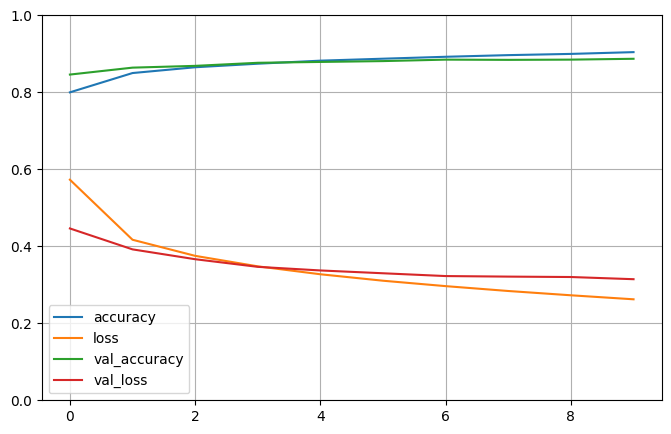

In [ ]:
import pandas as pd

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
#save_fig("keras_learning_curves_plot")
plt.show()

Una vez que esté **satisfecho con la precisión de validación de su modelo**, debe evaluarla en el *conjunto de prueba* (test) para estimar el error de generalización antes de implementar el modelo en producción:

In [ ]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8724 - loss: 0.3611


[0.3625572919845581, 0.871399998664856]

- Como vimos anteriormente, es **común obtener un rendimiento ligeramente inferior en el conjunto de prueba** que en el conjunto de validación, porque los hiperparámetros están sintonizados en el conjunto de validación, no en el conjunto de prueba.

## Usando el modelo para hacer predicciones
A continuación, podemos usar el método *predict()* del modelo para hacer predicciones sobre nuevas instancias. Como no tenemos instancias nuevas reales, solo usaremos las primeras 3 instancias del **conjunto de prueba**:

**Nota**: recuerde que configuaramos la red para que a la salida nos arroje la probabilidad de membresia por clase, por eso nos arroja un vector en 0 y 1.

In [ ]:
X_new = X_test[:10]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.04, 0.  , 0.95],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.07, 0.  , 0.05, 0.  , 0.  , 0.  , 0.87, 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.02, 0.  , 0.98, 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.99, 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 1.  , 0.  , 0.  ]],
      dtype=float32)

In [ ]:
y_pred = model.predict(X_new).argmax(axis=1) #podemos utilizar argmax para estimar la salida ordinal
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [ ]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt', 'Trouser',
       'Coat', 'Shirt', 'Sandal', 'Sneaker'], dtype='<U11')

In [ ]:
y_new = y_test[:3]
y_new

array([9, 2, 1], dtype=uint8)

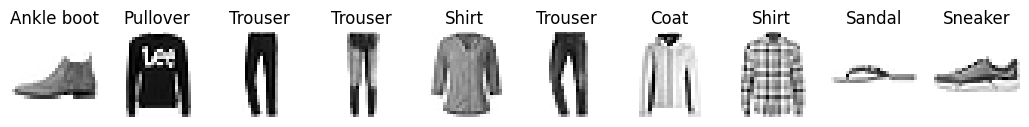

In [ ]:
plt.figure(figsize=(13, 2.4))
for index, image in enumerate(X_new):
    plt.subplot(1, 10, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_test[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
#save_fig('fashion_mnist_images_plot', tight_layout=False)
plt.show()

In [ ]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(1) #se fija una única con activacion lineal
])
model.compile(loss="mean_squared_error", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history  = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))
mse_test = model.evaluate(X_test, y_test)
X_new    = X_test[:3]
y_pred   = model.predict(X_new)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 11.2476 - val_loss: 8.2913
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2550 - val_loss: 8.2584
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2309 - val_loss: 8.2494
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2233 - val_loss: 8.2452
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2195 - val_loss: 8.2427
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2172 - val_loss: 8.2412
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2157 - val_loss: 8.2401
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2147 - val_loss: 8.2394
Epoch 9/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2140 - val_loss: 8.2388
Epoch 10/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2135 - val_loss: 8.2384
Epoch 11/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2131 - val_loss: 8.2380
Epoch 12/20
1719/1719 ━━━━━━━

In [ ]:
plt.plot(pd.DataFrame(history.history))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

NameError: name 'pd' is not defined

In [ ]:
y_pred

Como puede ver, la API secuencial es **bastante fácil de usar**. Sin embargo, aunque los modelos secuenciales son extremadamente comunes, a veces es útil construir redes neuronales con topologías más complejas, o con múltiples entradas o salidas. Para este propósito, Keras ofrece la **API funcional**.

# Ejercicio:

- Configure el entorno de Colab para trabajar con GPU (Ver pestaña entorno de ejecución). Repita el entrenamiento del modelo de clasificación Fashion mnist para batch size en 32, 64, 128, 256, y 512. Reporte una tabla con los rendimientos sobre el conjunto de test y el tiempo promedio de cómputo por época.

- Repita el procedimiento del punto anterior configurando Colab para trabajar con TPU.

In [ ]:
%pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 756.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.3 MB/s eta 0:00:00


In [ ]:
import time
import tensorflow as tf
from tensorflow import keras
import numpy as np

# Load Fashion MNIST dataset again to ensure correct data is used
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Split and scale the data
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.


batch_sizes = [32, 64, 128, 256, 512]
gpu_results = {}

# Clear previous TensorFlow session to avoid issues
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

# Define the model architecture (same as before)
def build_model():
    model = keras.models.Sequential([
        keras.layers.Flatten(input_shape=[28, 28]),
        keras.layers.Dense(300, activation="relu"),
        keras.layers.Dense(100, activation="relu"),
        keras.layers.Dense(10, activation="softmax")
    ])
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer="sgd",
                  metrics=["accuracy"])
    return model

for batch_size in batch_sizes:
    print(f"Training with batch size: {batch_size}")
    model = build_model()

    start_time = time.time()
    history = model.fit(X_train, y_train, epochs=10, batch_size=batch_size,
                        validation_data=(X_valid, y_valid), verbose=0) # Set verbose to 0 to reduce output during training
    end_time = time.time()

    # Calculate average time per epoch
    avg_time_per_epoch = (end_time - start_time) / history.params['epochs']
    print(f"Average time per epoch: {avg_time_per_epoch:.2f} seconds")

    # Evaluate the model on the test set
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0) # Set verbose to 0
    print(f"Test accuracy: {accuracy:.4f}")

    gpu_results[batch_size] = {'average_time_per_epoch': avg_time_per_epoch, 'test_accuracy': accuracy}
    print("-" * 30)

print("\nGPU Results:")
for batch_size, results in gpu_results.items():
    print(f"Batch Size {batch_size}: Accuracy = {results['test_accuracy']:.4f}, Avg Time/Epoch = {results['average_time_per_epoch']:.2f}s")

Training with batch size: 32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Average time per epoch: 4.23 seconds
Test accuracy: 0.8631
------------------------------
Training with batch size: 64
Average time per epoch: 2.28 seconds
Test accuracy: 0.8449
------------------------------
Training with batch size: 128
Average time per epoch: 1.37 seconds
Test accuracy: 0.8409
------------------------------
Training with batch size: 256
Average time per epoch: 0.85 seconds
Test accuracy: 0.8281
------------------------------
Training with batch size: 512
Average time per epoch: 0.71 seconds
Test accuracy: 0.8098
------------------------------

GPU Results:
Batch Size 32: Accuracy = 0.8631, Avg Time/Epoch = 4.23s
Batch Size 64: Accuracy = 0.8449, Avg Time/Epoch = 2.28s
Batch Size 128: Accuracy = 0.8409, Avg Time/Epoch = 1.37s
Batch Size 256: Accuracy = 0.8281, Avg Time/Epoch = 0.85s
Batch Size 512: Accuracy = 0.8098, Avg Time/Epoch = 0.71s


# TPU

In [ ]:
!pip install tensorflow tensorflow_gcs_config tensorflow_datasets -q


In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
!echo $COLAB_TPU_ADDR
!python3 -c "import tensorflow as tf; print(tf.config.list_logical_devices())"

In [ ]:
import time
import tensorflow as tf
from tensorflow import keras
import numpy as np

# ==============================
# 1️⃣ Conexión y estrategia TPU
# ==============================
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver.connect()
    strategy = tf.distribute.TPUStrategy(tpu)
    print("✅ TPU connected successfully.")
except Exception as e:
    print("❌ TPU not connected, running on CPU instead:", e)
    strategy = tf.distribute.get_strategy()

# ==============================
# 2️⃣ Carga de datos
# ==============================
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

batch_sizes = [32, 64, 128, 256, 512]
tpu_results = {}

keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

# ==============================
# 3️⃣ Definición del modelo
# ==============================
def build_model():
    model = keras.models.Sequential([
        keras.layers.Flatten(input_shape=[28, 28]),
        keras.layers.Dense(300, activation="relu"),
        keras.layers.Dense(100, activation="relu"),
        keras.layers.Dense(10, activation="softmax")
    ])
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="sgd",
        metrics=["accuracy"]
    )
    return model

# ==============================
# 4️⃣ Entrenamiento sobre TPU
# ==============================
for batch_size in batch_sizes:
    print(f"\n🔹 Training with batch size: {batch_size}")

    # El modelo debe crearse dentro del scope TPU
    with strategy.scope():
        model = build_model()

    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=batch_size,
        validation_data=(X_valid, y_valid),
        verbose=0
    )
    end_time = time.time()

    avg_time_per_epoch = (end_time - start_time) / history.params['epochs']
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    print(f"✅ Avg Time/Epoch: {avg_time_per_epoch:.2f}s | Test Accuracy: {accuracy:.4f}")
    tpu_results[batch_size] = {
        'average_time_per_epoch': avg_time_per_epoch,
        'test_accuracy': accuracy
    }

# ==============================
# 5️⃣ Mostrar tabla final
# ==============================
print("\n📊 TPU Results Summary:")
for batch_size, results in tpu_results.items():
    print(f"Batch {batch_size}: Accuracy = {results['test_accuracy']:.4f}, "
          f"Avg Time/Epoch = {results['average_time_per_epoch']:.2f}s")
